# PosteriorRepairRadius: estimated vs. true active-row errors

This notebook analyzes the output of `run_rmax_posterior_experiment.py`: for
many planted-low-weight-codeword instances of the LEP prediction stage, it
compares the **true** active error dimension `r(v)` (only knowable in this
controlled test, because the real secret `Q` is available) against the
**estimated** repair radius produced by the `PosteriorRepairRadius` idea.

**Grid vs. named instances:** every row also carries a `config_source`
column - `'grid'` rows come from the general `(n, k) x q x (alpha, beta)`
sweep in `run_rmax_posterior_experiment.py`; `'named'` rows come from three
specific test points added on request: `(n=128, k=64, q=127)`, `(n=252,
k=126, q=127)` (LESS-1, NIST Category 1) and `(n=548, k=274, q=127)`
(LESS-5, NIST Category 5 - the highest security level LESS defines).


In [ ]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CAT = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
SEQ_BLUE = ['#cde2fb', '#9ec5f4', '#5598e7', '#256abf', '#0d366b']
TEXT_PRIMARY = '#0b0b0b'
TEXT_SECONDARY = '#52514e'
GRID = '#e5e4e0'

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': GRID, 'axes.grid': True, 'grid.color': GRID,
    'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'text.color': TEXT_PRIMARY, 'axes.labelcolor': TEXT_PRIMARY,
    'xtick.color': TEXT_SECONDARY, 'ytick.color': TEXT_SECONDARY,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

# path to results
_real_candidates = sorted(glob.glob('csv_results/rmax_posterior_results_2*.csv'))
CSV_PATH = _real_candidates[-1] if _real_candidates else 'rmax_posterior_results_DEMO.csv'
print(f"Loading: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
print(f"{len(df)} rows loaded.")


Loading: csv_results/rmax_posterior_results_20260901T013845.csv
162 rows loaded.


## Overview

In [ ]:
# count number of errors
n_errors = (df['error'].fillna('') != '').sum()
print(f"Instances with an error: {n_errors} / {len(df)}")
if n_errors:
    display(df[df['error'].fillna('') != ''][['n', 'k', 'q', 'alpha', 'beta', 'seed', 'error']])

df_ok = df[df['error'].fillna('') == ''].copy()
if 'config_source' not in df_ok.columns:
    df_ok['config_source'] = 'grid'  # older CSVs (pre-config_source) are all grid sweeps
print(df_ok['config_source'].value_counts().to_string())

df_ok[['n', 'k', 'q', 'alpha', 'beta', 't_active', 'r_v_true', 'mean_est_r',
       'rmax_90', 'rmax_95', 'rmax_99']].describe().round(2)


Instances with an error: 0 / 162
config_source
grid     135
named     27


,n,k,q,alpha,beta,t_active,r_v_true,mean_est_r,rmax_90,rmax_95,rmax_99
count,162.00,162.00,162.00,162.00,162.00,162.00,162.00,162.00,162.00,162.00,162.0
mean,113.78,56.89,66.44,0.01,0.05,44.02,18.05,23.09,26.17,27.01,28.7
std,119.32,59.66,54.95,0.00,0.02,48.70,24.11,28.12,29.44,29.82,30.5
min,32.00,16.00,7.00,0.01,0.03,11.00,0.00,2.00,4.00,4.00,5.0
25%,32.00,16.00,7.00,0.01,0.03,15.00,5.00,7.69,9.25,10.00,11.0
50%,64.00,32.00,29.00,0.01,0.05,28.00,11.00,15.03,17.50,18.00,19.0
75%,128.00,64.00,127.00,0.02,0.08,54.00,22.00,26.65,30.00,31.00,32.0
max,548.00,274.00,127.00,0.02,0.08,222.00,148.00,164.39,172.00,174.00,178.0


## Headline instances: n=128, n=252 (LESS-1), n=548 (LESS-5)

The three specific test points requested on top of the general grid, pulled out on their own since they're the ones that matter most for sizing the real repair module (LESS-1 and LESS-5 are actual NIST PQC parameter sets, not arbitrary sweep points).


In [3]:
named = df_ok[df_ok['config_source'] == 'named'].copy()
if named.empty:
    print("No 'named' rows in this CSV yet.")
else:
    cols = ['n', 'k', 'q', 'alpha', 'beta', 'seed', 't_active', 'r_v_true',
            'mean_est_r', 'rmax_90', 'coverage_90', 'rmax_95', 'coverage_95',
            'rmax_99', 'coverage_99', 'elapsed_posterior_s', 'elapsed_hungarian_s']
    display(named[cols].sort_values(['n', 'alpha', 'beta']).reset_index(drop=True))

    present_sizes = sorted(named[['n', 'k', 'q']].drop_duplicates().itertuples(index=False, name=None))
    expected_sizes = [(128, 64, 127), (252, 126, 127), (548, 274, 127)]
    missing = [s for s in expected_sizes if s not in present_sizes]
    if missing:
        print(f"\nNot yet present in this CSV: {missing}")


,n,k,q,alpha,beta,seed,t_active,r_v_true,mean_est_r,rmax_90,coverage_90,rmax_95,coverage_95,rmax_99,coverage_99,elapsed_posterior_s,elapsed_hungarian_s
0,128,64,127,0.01,0.03,20260966,54,10,17.549739,21,1,22,1,24,1,0.287495,0.607646
1,128,64,127,0.01,0.03,20260967,54,15,15.972761,19,1,20,1,22,1,0.285305,0.607222
2,128,64,127,0.01,0.03,20260968,54,8,15.703151,19,1,20,1,22,1,0.286475,0.610406
3,128,64,127,0.01,0.05,20260969,54,7,23.265599,27,1,28,1,30,1,0.299901,0.619702
4,128,64,127,0.01,0.05,20260970,54,17,23.890147,28,1,29,1,31,1,0.376665,0.679621
5,128,64,127,0.01,0.05,20260971,54,20,23.560219,28,1,29,1,31,1,0.318975,0.633424
6,128,64,127,0.02,0.08,20260972,54,24,33.284481,37,1,38,1,41,1,0.310591,0.571749
7,128,64,127,0.02,0.08,20260973,54,31,32.040142,36,1,37,1,39,1,0.306231,0.579067
8,128,64,127,0.02,0.08,20260974,54,21,32.122384,36,1,37,1,40,1,0.302776,0.566914
9,252,126,127,0.01,0.03,20260975,103,23,42.411571,47,1,49,1,51,1,1.147704,2.387641


## Calibration: does the estimate track the truth?

`mean_est_r = sum(p_i)` is the Poisson-binomial mean - the estimator's single best guess at `r(v)`, before any confidence-level padding. Points on the dashed `y = x` line mean the estimate matched the true count exactly; points above it mean the estimate over-predicted (conservative - the more
common and safer direction), points below mean it under-predicted.


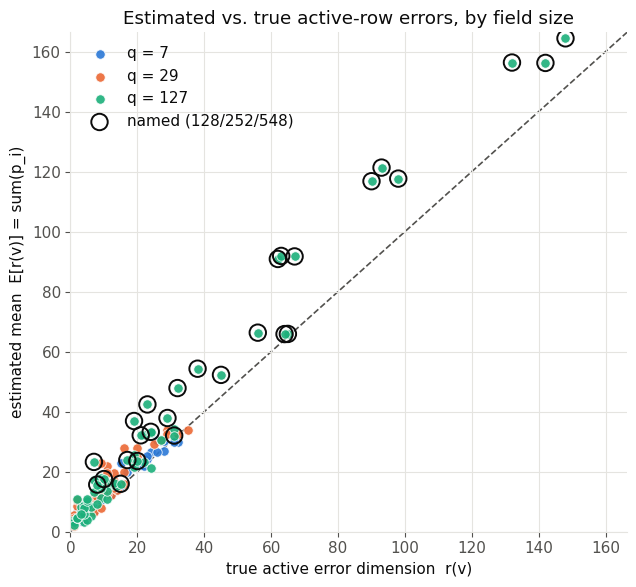

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 6))

q_values = sorted(df_ok['q'].unique())[:3]  # first 3 categorical slots validate all-pairs
for i, q in enumerate(q_values):
    sub = df_ok[df_ok['q'] == q]
    ax.scatter(sub['r_v_true'], sub['mean_est_r'], s=46, color=CAT[i],
               edgecolor='white', linewidth=0.6, alpha=0.9, label=f'q = {q}')

named_pts = df_ok[df_ok['config_source'] == 'named']
if not named_pts.empty:
    ax.scatter(named_pts['r_v_true'], named_pts['mean_est_r'], s=140, facecolors='none',
               edgecolors=TEXT_PRIMARY, linewidth=1.4, marker='o', label='named (128/252/548)', zorder=4)

lim = max(df_ok['r_v_true'].max(), df_ok['mean_est_r'].max()) + 2
ax.plot([0, lim], [0, lim], linestyle='--', color=TEXT_SECONDARY, linewidth=1.2, zorder=0)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('true active error dimension  r(v)')
ax.set_ylabel('estimated mean  E[r(v)] = sum(p_i)')
ax.set_title('Estimated vs. true active-row errors, by field size')
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.savefig('fig_calibration_scatter.png', dpi=150)
plt.show()


## Coverage: how often does the true count actually stay within the estimated radius?

For each confidence level `1 - delta`, `coverage_XX` is 1 exactly when `r_v_true <= rmax_XX` for that instance. If the estimate is well-calibrated,
the empirical coverage rate should sit **at or above** its target (e.g. the 95% bar should cover at least ~95% of instances).


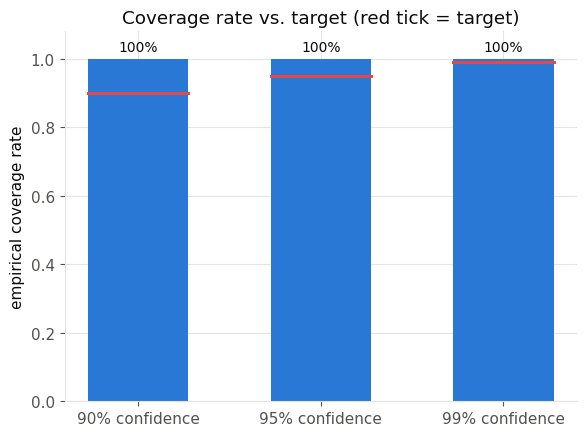

,confidence,target,empirical_coverage,n_instances
0,90%,0.90,1.0,162
1,95%,0.95,1.0,162
2,99%,0.99,1.0,162


In [5]:
levels = [('90', 0.90), ('95', 0.95), ('99', 0.99)]
rates = [df_ok[f'coverage_{lab}'].mean() for lab, _ in levels]
targets = [t for _, t in levels]

fig, ax = plt.subplots(figsize=(6, 4.5))
x = np.arange(len(levels))
bars = ax.bar(x, rates, width=0.55, color=CAT[0])
for xi, target in zip(x, targets):
    ax.plot([xi - 0.275, xi + 0.275], [target, target], color=CAT[7], linewidth=2.2, zorder=3)
for xi, rate in zip(x, rates):
    ax.text(xi, rate + 0.015, f'{rate:.0%}', ha='center', va='bottom',
             color=TEXT_PRIMARY, fontsize=10)

ax.set_xticks(x); ax.set_xticklabels([f'{lab}% confidence' for lab, _ in levels])
ax.set_ylim(0, 1.08)
ax.set_ylabel('empirical coverage rate')
ax.set_title('Coverage rate vs. target (red tick = target)')
plt.tight_layout()
plt.savefig('fig_coverage_bars.png', dpi=150)
plt.show()

pd.DataFrame({'confidence': [f'{lab}%' for lab, _ in levels], 'target': targets,
              'empirical_coverage': [round(r, 4) for r in rates],
              'n_instances': [len(df_ok)] * 3})


## Slack: how much repair budget is "wasted" at 99% confidence?

`slack = rmax_99 - r_v_true`. Zero means the estimate was exactly tight for that instance; larger values mean the repair module would be configured for
more active-row errors than actually occurred. A left-skewed histogram concentrated near 0 is the desirable shape.


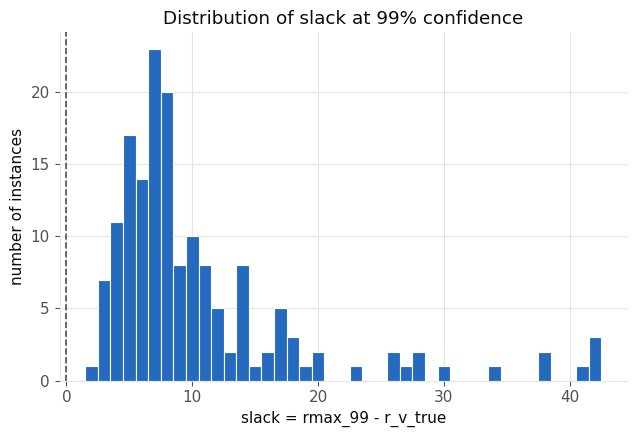

median slack = 8.0, mean slack = 10.65, instances with negative slack (undercoverage) = 0 / 162


In [6]:
slack = df_ok['rmax_99'] - df_ok['r_v_true']

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bins = np.arange(slack.min() - 0.5, slack.max() + 1.5, 1)
ax.hist(slack, bins=bins, color=SEQ_BLUE[3], edgecolor='white', linewidth=0.8)
ax.axvline(0, color=TEXT_SECONDARY, linewidth=1.2, linestyle='--')
ax.set_xlabel('slack = rmax_99 - r_v_true')
ax.set_ylabel('number of instances')
ax.set_title('Distribution of slack at 99% confidence')
plt.tight_layout()
plt.savefig('fig_slack_hist.png', dpi=150)
plt.show()

print(f"median slack = {slack.median():.1f}, mean slack = {slack.mean():.2f}, "
      f"instances with negative slack (undercoverage) = {(slack < 0).sum()} / {len(slack)}")


## Effect of noise quality (alpha, beta)

Mean true `r(v)` vs. mean estimated `R_max` at 99% confidence, grouped by `(alpha, beta)`. Noisier channels (larger alpha/beta) should push both up
together.


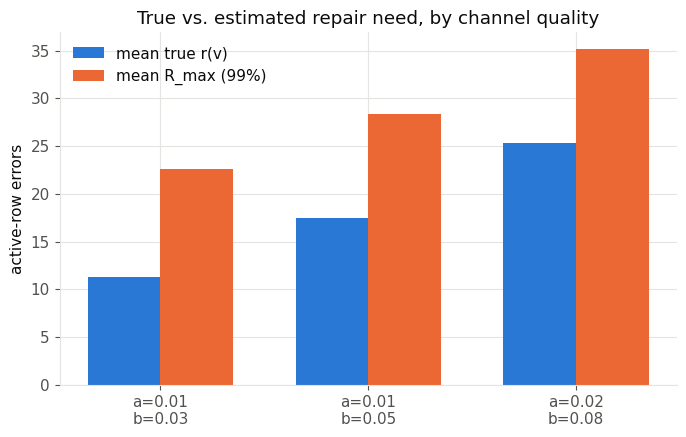

,alpha,beta,n,mean_r_v_true,mean_rmax_99
0,0.01,0.03,54,11.30,22.61
1,0.01,0.05,54,17.50,28.33
2,0.02,0.08,54,25.35,35.15


In [7]:
grouped = df_ok.groupby(['alpha', 'beta']).agg(
    mean_r_v_true=('r_v_true', 'mean'),
    mean_rmax_99=('rmax_99', 'mean'),
    n=('r_v_true', 'size'),
).reset_index()
grouped['label'] = grouped.apply(lambda r: f"a={r['alpha']:g}\nb={r['beta']:g}", axis=1)

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(grouped))
width = 0.35
ax.bar(x - width / 2, grouped['mean_r_v_true'], width=width, color=CAT[0], label='mean true r(v)')
ax.bar(x + width / 2, grouped['mean_rmax_99'], width=width, color=CAT[1], label='mean R_max (99%)')
ax.set_xticks(x); ax.set_xticklabels(grouped['label'])
ax.set_ylabel('active-row errors')
ax.set_title('True vs. estimated repair need, by channel quality')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('fig_alpha_beta_bars.png', dpi=150)
plt.show()

grouped[['alpha', 'beta', 'n', 'mean_r_v_true', 'mean_rmax_99']].round(2)


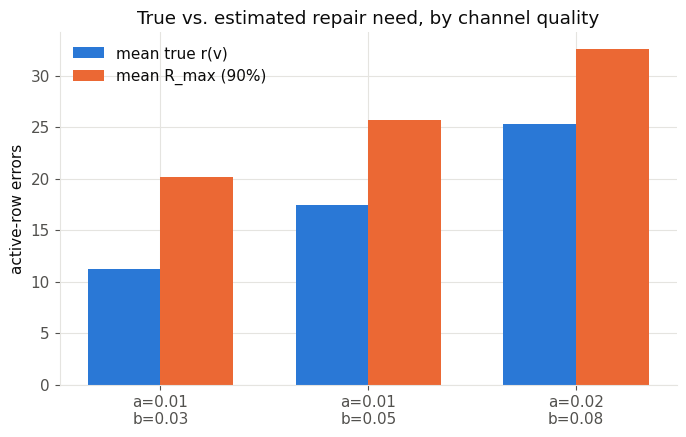

,alpha,beta,n,mean_r_v_true,mean_rmax_90
0,0.01,0.03,54,11.30,20.15
1,0.01,0.05,54,17.50,25.76
2,0.02,0.08,54,25.35,32.61


In [11]:
grouped = df_ok.groupby(['alpha', 'beta']).agg(
    mean_r_v_true=('r_v_true', 'mean'),
    mean_rmax_90=('rmax_90', 'mean'),
    n=('r_v_true', 'size'),
).reset_index()
grouped['label'] = grouped.apply(lambda r: f"a={r['alpha']:g}\nb={r['beta']:g}", axis=1)

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(grouped))
width = 0.35
ax.bar(x - width / 2, grouped['mean_r_v_true'], width=width, color=CAT[0], label='mean true r(v)')
ax.bar(x + width / 2, grouped['mean_rmax_90'], width=width, color=CAT[1], label='mean R_max (90%)')
ax.set_xticks(x); ax.set_xticklabels(grouped['label'])
ax.set_ylabel('active-row errors')
ax.set_title('True vs. estimated repair need, by channel quality')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('fig_alpha_beta_bars.png', dpi=150)
plt.show()

grouped[['alpha', 'beta', 'n', 'mean_r_v_true', 'mean_rmax_90']].round(2)


## Timing

Time taken per stage, by field length.

In [8]:
timing = df_ok.groupby('n').agg(
    mean_posterior_s=('elapsed_posterior_s', 'mean'),
    mean_hungarian_s=('elapsed_hungarian_s', 'mean'),
    mean_estimate_s=('elapsed_estimate_s', 'mean'),
    n_instances=('n', 'size'),
).reset_index()
timing.round(4)


,n,mean_posterior_s,mean_hungarian_s,mean_estimate_s,n_instances
0,32,0.0131,0.0235,0.0033,45
1,64,0.0365,0.0946,0.0121,45
2,128,0.1667,0.4305,0.0576,54
3,252,1.1474,2.3822,0.4111,9
4,548,5.4458,11.6321,1.9017,9
